# Question:
## Does a highschoolers grade associate with the amount of school work pressure a student feels? 
# Study Type:
### This is a observational study because were only taking data from kids who have taken the survey and were only observing data of highschoolers (grades 9-12).

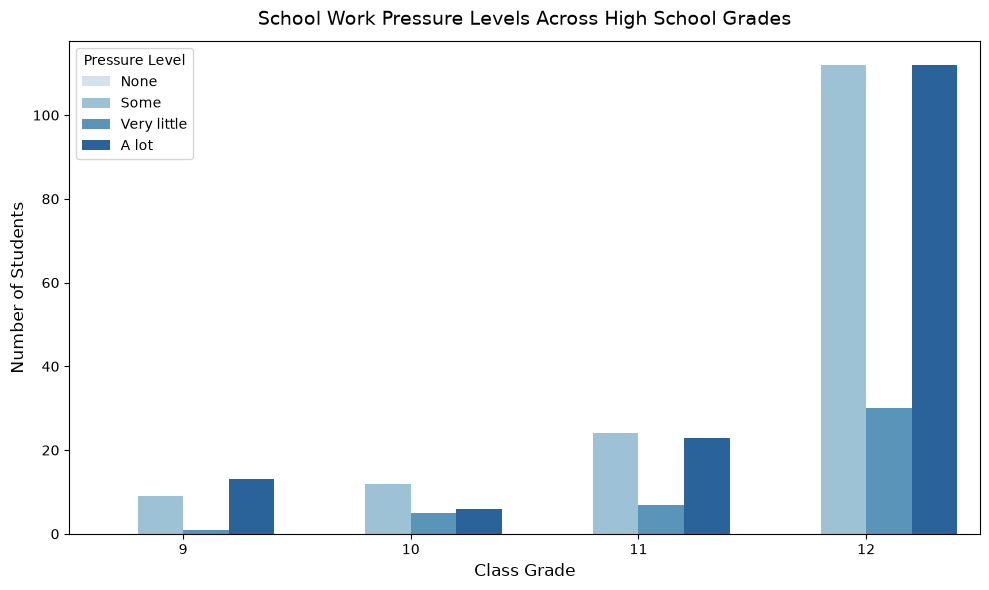

Schoolwork_Pressure,A lot,Some,Very little,Total
ClassGrade,,,,
9,13,9,1,23
10,6,12,5,23
11,23,24,7,54
12,112,112,30,254
Total,154,157,43,354


In [32]:
#These are all my imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#This is reading the data into jupyter
teenagers = pd.read_csv("CensusAtSchool.csv")

#Creating the graph
hs_teens = teenagers[teenagers["ClassGrade"].astype(str).isin(["9", "10", "11", "12"])].copy()
plt.figure(figsize=(10,6))
ax = sns.countplot(
    data=hs_teens,
    x="ClassGrade",
    hue="Schoolwork_Pressure",  
    order=["9", "10", "11", "12"],
    hue_order=["None", "Some", "Very little", "A lot"],  
    palette="Blues"
)
plt.title("School Work Pressure Levels Across High School Grades", fontsize=14, pad=12)
plt.xlabel("Class Grade", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.legend(title="Pressure Level")
plt.tight_layout()
plt.show()

#Making the two way table
crosstab_table = pd.crosstab(
    index=hs_teens["ClassGrade"], 
    columns=hs_teens["Schoolwork_Pressure"],
    margins=True,            
    margins_name="Total"     
)

crosstab_table

In [29]:
joint_and_marginal = pd.crosstab(
    index=hs_teens["ClassGrade"], 
    columns=hs_teens["Schoolwork_Pressure"],
    margins=True,       
    margins_name="Total",
    normalize=True      
) * 100

joint_and_marginal

Schoolwork_Pressure,A lot,Some,Very little,Total
ClassGrade,,,,
9,3.672316,2.542373,0.282486,6.497175
10,1.694915,3.389831,1.412429,6.497175
11,6.497175,6.779661,1.977401,15.254237
12,31.638418,31.638418,8.474576,71.751412
Total,43.502825,44.350282,12.146893,100.000000


In [26]:
conditional_by_grade = pd.crosstab(
    index=hs_teens["ClassGrade"], 
    columns=hs_teens["Schoolwork_Pressure"],
    normalize="index"   
) * 100

conditional_by_grade

Schoolwork_Pressure,A lot,Some,Very little
ClassGrade,,,
9,56.521739,39.130435,4.347826
10,26.086957,52.173913,21.739130
11,42.592593,44.444444,12.962963
12,44.094488,44.094488,11.811024


In [27]:
conditional_by_pressure = pd.crosstab(
    index=hs_teens["ClassGrade"], 
    columns=hs_teens["Schoolwork_Pressure"],
    normalize="columns" 
) * 100

conditional_by_pressure

Schoolwork_Pressure,A lot,Some,Very little
ClassGrade,,,
9,8.441558,5.732484,2.325581
10,3.896104,7.643312,11.627907
11,14.935065,15.286624,16.279070
12,72.727273,71.337580,69.767442


# Analysis:

### Based on the graph and the data, there seems to be no correlation between grade and pressure level a student feels. All the graphs for the different grades seem to have the same shape, there just were more seniors that answered. There was a lot of "some" or "a lot" for each grade level. 